In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [91]:
# =====================================================================
# BAGIAN 1:
# =====================================================================

class DataPreprocessor:
    """
    Kelas untuk melakukan preprocessing data startup failure prediction
    """

    def __init__(self, data_path):
        self.data_path = data_path
        self.data = None
        self.processed_data = None

    def load_data(self):
        """Memuat data dari file CSV"""
        self.data = pd.read_csv(self.data_path)
        print("Data berhasil dimuat!")
        print(f"Shape data: {self.data.shape}")
        return self.data

    def explore_data(self):
        """Eksplorasi data untuk memahami struktur dan distribusi"""
        print("\n=== EKSPLORASI DATA ===")
        print("\nInfo Dataset:")
        print(self.data.info())

        print("\nSample Data:")
        print(self.data.head())

        print("\nDistribusi Target (StaStatus):")
        print(self.data['Startup_Status'].value_counts())

        # Visualisasi distribusi fitur numerik
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))
        fig.suptitle("Distribusi Fitur Dataset Startup", fontsize=16)

        self.data["Startup_Age"].hist(bins=10, ax=axes[0, 0], edgecolor="black")
        axes[0, 0].set_title("Startup_Age")

        self.data["Number_of_Founders"].hist(bins=10, ax=axes[0, 1], edgecolor="black")
        axes[0, 1].set_title("Number_of_Founders")

        self.data["Employees_Count"].hist(bins=10, ax=axes[1, 0], edgecolor="black")
        axes[1, 0].set_title("Employees_Count")

        self.data["Funding_Amount"].hist(bins=10, ax=axes[1, 1], edgecolor="black")
        plt.tight_layout()
        axes[1, 1].set_title("Funding_Amount")

        # Depression (Target)
        self.data['Depression'].value_counts().plot(kind='bar', ax=axes[1,2])
        axes[1,2].set_title('Depression (Target)')

        plt.show()

    def preprocess_data(self):
        """
        Preprocessing data:
        1. Normalisasi fitur numerik
        2. Encoding target
        3. Pembentukan skor gabungan (optional)
        """
        print("\n=== PREPROCESSING DATA ===")
        processed = self.data.copy()

        # 1. Normalisasi fitur numerik
        for col in [
            "Startup_Age",
            "Number_of_Founders",
            "Employees_Count",
            "Funding_Amount",
        ]:
            if col in processed.columns:
                norm_col = col.replace(" ", "_") + "_Norm"
                processed[norm_col] = (processed[col] - processed[col].min()) / (
                    processed[col].max() - processed[col].min()
                )

        # 2. Encoding target
        if "Failed" in processed.columns:
            processed["Failed_Numeric"] = processed["Failed"].map({"No": 0, "Yes": 1})

        # 3. Pembentukan skor gabungan risiko kegagalan (optional)
        processed["Risk_Score"] = (
            processed["Startup_Age_Norm"] * 0.2
            + (1 - processed["Funding_Amount_Norm"])
            * 0.4  # pendanaan rendah -> risiko tinggi
            + (1 - processed["Employees_Count_Norm"]) * 0.2
            + (1 - processed["Number_of_Founders_Norm"]) * 0.2
        )

        self.processed_data = processed
        print("Preprocessing selesai!")

        # Tampilkan statistik
        print("\nStatistik Fitur Terproses:")
        print(processed.describe())

        return processed

In [92]:
# =====================================================================
# BAGIAN 2:
# =====================================================================

class FuzzyMembershipFunctions:
    """
    Kelas untuk mendefinisikan fungsi keanggotaan fuzzy
    untuk fitur-fitur startup seperti usia, pendiri, karyawan, dan pendanaan.
    """

    @staticmethod
    def trimf(x, a, b, c):
        """
        Fungsi keanggotaan segitiga (Triangular Membership Function)
        Digunakan untuk menentukan keanggotaan fuzzy dalam rentang (a, b, c)
        """
        left = 0 if b == a else (x - a) / (b - a)
        right = 0 if c == b else (c - x) / (c - b)
        return np.maximum(0, np.minimum(left, right))

    @staticmethod
    def trapmf(x, a, b, c, d):
        """
        Fungsi keanggotaan trapezoidal (Trapezoidal Membership Function)
        Berguna untuk rentang nilai yang stabil di tengah (b, c)
        """
        return np.maximum(
            0, np.minimum(np.minimum((x - a) / (b - a), 1), (d - x) / (d - c))
        )

    @staticmethod
    def gaussmf(x, mean, sigma):
        """
        Fungsi keanggotaan Gaussian Membership Function
        Cocok untuk data yang distribusinya normal
        """
        return np.exp(-0.5 * ((x - mean) / sigma) ** 2)

    # ---------------------------------------------------------------
    # Contoh fungsi keanggotaan fuzzy untuk fitur Startup
    # ---------------------------------------------------------------

    @staticmethod
    def startup_age_low(x):
        return FuzzyMembershipFunctions.trapmf(x, 0, 0, 1, 3)

    @staticmethod
    def startup_age_medium(x):
        return FuzzyMembershipFunctions.trimf(x, 2, 5, 8)

    @staticmethod
    def startup_age_high(x):
        return FuzzyMembershipFunctions.trapmf(x, 6, 8, 12, 15)

    @staticmethod
    def funding_low(x):
        return FuzzyMembershipFunctions.trapmf(x, 0, 0, 20000, 50000)

    @staticmethod
    def funding_medium(x):
        return FuzzyMembershipFunctions.trimf(x, 30000, 80000, 130000)

    @staticmethod
    def funding_high(x):
        return FuzzyMembershipFunctions.trapmf(x, 100000, 150000, 300000, 500000)

    @staticmethod
    def employees_few(x):
        return FuzzyMembershipFunctions.trapmf(x, 0, 0, 5, 10)

    @staticmethod
    def employees_moderate(x):
        return FuzzyMembershipFunctions.trimf(x, 8, 20, 35)

    @staticmethod
    def employees_many(x):
        return FuzzyMembershipFunctions.trapmf(x, 30, 50, 100, 200)

    @staticmethod
    def founders_few(x):
        return FuzzyMembershipFunctions.trapmf(x, 0, 0, 1, 2)

    @staticmethod
    def founders_moderate(x):
        return FuzzyMembershipFunctions.trimf(x, 2, 3, 4)

    @staticmethod
    def founders_many(x):
        return FuzzyMembershipFunctions.trapmf(x, 4, 5, 6, 7)

In [93]:
# =====================================================================
# BAGIAN 3:
# =====================================================================

class MamdaniFIS:
    """
    Fuzzy Inference System menggunakan metode Mamdani untuk prediksi status startup.
    """

    def __init__(self):
        self.membership_functions = {}
        self.rules = []
        self.setup_membership_functions()
        self.setup_rules()

    def setup_membership_functions(self):
        """Definisi fungsi keanggotaan untuk setiap variabel"""
        self.membership_functions["Startup_Age"] = {
            "new": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 2),
            "growing": lambda x: FuzzyMembershipFunctions.trimf(x, 1, 3, 5),
            "established": lambda x: FuzzyMembershipFunctions.trimf(x, 4, 6, 10),
        }

        self.membership_functions["Number_of_Founder"] = {
            "few": lambda x: FuzzyMembershipFunctions.trimf(x, 1, 1, 2),
            "moderate": lambda x: FuzzyMembershipFunctions.trimf(x, 1.5, 3, 4.5),
            "many": lambda x: FuzzyMembershipFunctions.trimf(x, 3, 5, 7),
        }

        self.membership_functions["Employees_Count"] = {
            "small": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 10),
            "medium": lambda x: FuzzyMembershipFunctions.trimf(x, 5, 20, 50),
            "large": lambda x: FuzzyMembershipFunctions.trimf(x, 30, 100, 200),
        }

        self.membership_functions["Funding_Amount"] = {
            "low": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 100000),
            "medium": lambda x: FuzzyMembershipFunctions.trimf(
                x, 50000, 250000, 500000
            ),
            "high": lambda x: FuzzyMembershipFunctions.trimf(
                x, 300000, 1000000, 2000000
            ),
        }

        self.membership_functions["status"] = {
            "fail": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 0.5),
            "uncertain": lambda x: FuzzyMembershipFunctions.trimf(x, 0.25, 0.5, 0.75),
            "success": lambda x: FuzzyMembershipFunctions.trimf(x, 0.5, 1, 1),
        }

    def setup_rules(self):
        """Definisi aturan fuzzy"""
        self.rules = [
            (("new", "few", "small", "low"), "fail"),
            (("growing", "moderate", "medium", "medium"), "uncertain"),
            (("established", "many", "large", "high"), "success"),
            (("new", "few", "medium", "medium"), "uncertain"),
            (("established", "few", "small", "low"), "fail"),
            (("growing", "many", "medium", "high"), "success"),
            (("growing", "few", "small", "low"), "fail"),
            (("established", "moderate", "medium", "medium"), "success"),
        ]

    def fuzzify(self, age, founders, employees, funding):
        fuzzified = {
            "Startup_Age": {
                k: f(age) for k, f in self.membership_functions["Startup_Age"].items()
            },
            "Number_of_Founder": {
                k: f(founders)
                for k, f in self.membership_functions["Number_of_Founder"].items()
            },
            "Employees_Count": {
                k: f(employees)
                for k, f in self.membership_functions["Employees_Count"].items()
            },
            "Funding_Amount": {
                k: f(funding)
                for k, f in self.membership_functions["Funding_Amount"].items()
            },
        }
        return fuzzified

    def apply_rules(self, fuzzified_inputs):
        rule_outputs = {"fail": [], "uncertain": [], "success": []}

        for rule_antecedent, rule_consequent in self.rules:
            age_term, founder_term, emp_term, fund_term = rule_antecedent

            strength = min(
                fuzzified_inputs["Startup_Age"][age_term],
                fuzzified_inputs["Number_of_Founder"][founder_term],
                fuzzified_inputs["Employees_Count"][emp_term],
                fuzzified_inputs["Funding_Amount"][fund_term],
            )

            if strength > 0:
                rule_outputs[rule_consequent].append(strength)

        aggregated_output = {k: max(v) if v else 0 for k, v in rule_outputs.items()}
        return aggregated_output

    def defuzzify(self, aggregated_output):
        output_range = np.arange(0, 1.01, 0.01)
        membership_degrees = np.zeros_like(output_range)

        for i, x in enumerate(output_range):
            fail_m = min(
                aggregated_output["fail"],
                self.membership_functions["status"]["fail"](x),
            )
            uncertain_m = min(
                aggregated_output["uncertain"],
                self.membership_functions["status"]["uncertain"](x),
            )
            success_m = min(
                aggregated_output["success"],
                self.membership_functions["status"]["success"](x),
            )

            membership_degrees[i] = max(fail_m, uncertain_m, success_m)

        if np.sum(membership_degrees) == 0:
            return 0.5

        centroid = np.sum(output_range * membership_degrees) / np.sum(
            membership_degrees
        )
        return centroid

    def predict(self, age, founders, employees, funding):
        fuzzified = self.fuzzify(age, founders, employees, funding)
        aggregated = self.apply_rules(fuzzified)
        result = self.defuzzify(aggregated)
        return result

In [94]:
# =====================================================================
# BAGIAN 4:
# =====================================================================

class SugenoFIS:
    """
    Fuzzy Inference System menggunakan metode Sugeno untuk prediksi status startup.
    """

    def __init__(self):
        self.membership_functions = {}
        self.rules = []
        self.setup_membership_functions()
        self.setup_rules()

    def setup_membership_functions(self):
        """Fungsi keanggotaan untuk input startup"""
        self.membership_functions["Startup_Age"] = {
            "new": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 2),
            "growing": lambda x: FuzzyMembershipFunctions.trimf(x, 1, 3, 5),
            "established": lambda x: FuzzyMembershipFunctions.trimf(x, 4, 6, 10),
        }

        self.membership_functions["Number_of_Founder"] = {
            "few": lambda x: FuzzyMembershipFunctions.trimf(x, 1, 1, 2),
            "moderate": lambda x: FuzzyMembershipFunctions.trimf(x, 1.5, 3, 4.5),
            "many": lambda x: FuzzyMembershipFunctions.trimf(x, 3, 5, 7),
        }

        self.membership_functions["Employees_Count"] = {
            "small": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 10),
            "medium": lambda x: FuzzyMembershipFunctions.trimf(x, 5, 20, 50),
            "large": lambda x: FuzzyMembershipFunctions.trimf(x, 30, 100, 200),
        }

        self.membership_functions["Funding_Amount"] = {
            "low": lambda x: FuzzyMembershipFunctions.trimf(x, 0, 0, 100000),
            "medium": lambda x: FuzzyMembershipFunctions.trimf(
                x, 50000, 250000, 500000
            ),
            "high": lambda x: FuzzyMembershipFunctions.trimf(
                x, 300000, 1000000, 2000000
            ),
        }

    def setup_rules(self):
        """
        Definisikan aturan Sugeno.
        Format: (startup_age_term, founders_term, employees_term, funding_term) => (a,b,c,d,e)
        f = a*age + b*founders + c*employees + d*funding + e
        """
        self.rules = [
            (("new", "few", "small", "low"), (0.0, 0.0, 0.0, 0.0, 0.2)),
            (
                ("growing", "moderate", "medium", "medium"),
                (0.01, 0.02, 0.0005, 0.0000005, 0.3),
            ),
            (
                ("established", "many", "large", "high"),
                (0.02, 0.03, 0.0008, 0.000001, 0.5),
            ),
            (("new", "few", "medium", "medium"), (0.01, 0.01, 0.0003, 0.0000004, 0.25)),
            (
                ("established", "few", "small", "low"),
                (0.01, 0.01, 0.0001, 0.0000002, 0.2),
            ),
            (
                ("growing", "many", "medium", "high"),
                (0.015, 0.02, 0.0004, 0.0000008, 0.45),
            ),
            (("growing", "few", "small", "low"), (0.01, 0.01, 0.0002, 0.0000003, 0.25)),
            (
                ("established", "moderate", "medium", "medium"),
                (0.02, 0.02, 0.0005, 0.0000007, 0.4),
            ),
        ]

    def fuzzify(self, age, founders, employees, funding):
        """Fuzzifikasi input"""
        return {
            "Startup_Age": {
                k: f(age) for k, f in self.membership_functions["Startup_Age"].items()
            },
            "Number_of_Founder": {
                k: f(founders)
                for k, f in self.membership_functions["Number_of_Founder"].items()
            },
            "Employees_Count": {
                k: f(employees)
                for k, f in self.membership_functions["Employees_Count"].items()
            },
            "Funding_Amount": {
                k: f(funding)
                for k, f in self.membership_functions["Funding_Amount"].items()
            },
        }

    def apply_rules_and_defuzzify(
        self, fuzzified_inputs, age, founders, employees, funding
    ):
        weighted_sum = 0
        total_weight = 0

        for rule_antecedent, coeffs in self.rules:
            age_term, founder_term, emp_term, fund_term = rule_antecedent
            a, b, c, d, e = coeffs

            strength = min(
                fuzzified_inputs["Startup_Age"][age_term],
                fuzzified_inputs["Number_of_Founder"][founder_term],
                fuzzified_inputs["Employees_Count"][emp_term],
                fuzzified_inputs["Funding_Amount"][fund_term],
            )

            if strength > 0:
                output = a * age + b * founders + c * employees + d * funding + e
                output = max(0, min(1, output))  # Clamp [0, 1]
                weighted_sum += strength * output
                total_weight += strength

        return weighted_sum / total_weight if total_weight > 0 else 0.5

    def predict(self, age, founders, employees, funding):
        fuzzified = self.fuzzify(age, founders, employees, funding)
        return self.apply_rules_and_defuzzify(
            fuzzified, age, founders, employees, funding
        )

In [95]:
# =====================================================================
# BAGIAN 5:
# =====================================================================

class FuzzySystemEvaluator:
    """
    Kelas untuk evaluasi dan perbandingan sistem fuzzy berdasarkan data startup
    """

    def __init__(self, data):
        self.data = data
        self.mamdani_fis = MamdaniFIS()
        self.sugeno_fis = SugenoFIS()

    def prepare_data(self):
        print("Kolom-kolom data:", self.data.columns.tolist())
        """Persiapan data untuk evaluasi"""
        # Konversi kolom target jika belum dalam bentuk numerik
        self.data["Status_Numeric"] = self.data["Startup_Status"].apply(
            lambda x: 1 if x == "No" or x == 0 else 0
        )

        # Pilih fitur input untuk FIS (silakan sesuaikan jika berbeda)
        X = self.data[["Startup_Age", "Number_of_Founders", "Funding_Amount", "Employees_Count"]].values
        y = self.data["Status_Numeric"].values

        # Split data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y
        )
        return X_train, X_test, y_train, y_test

    def evaluate_system(self, fis_model, X_test, y_test, system_name):
        """Evaluasi satu sistem fuzzy"""
        print(f"\n=== EVALUASI SISTEM {system_name.upper()} ===")
        y_pred_fuzzy = []
        fuzzy_outputs = []

        for i in range(len(X_test)):
            age, founder, funding, employees = X_test[i]
            fuzzy_output = fis_model.predict(age, founder, funding, employees)
            fuzzy_outputs.append(fuzzy_output)
            binary_prediction = 1 if fuzzy_output > 0.5 else 0
            y_pred_fuzzy.append(binary_prediction)

        # Akurasi
        accuracy = accuracy_score(y_test, y_pred_fuzzy)
        print(f"Akurasi {system_name}: {accuracy:.4f} ({accuracy * 100:.2f}%)")

        print("Distribusi y_test:", np.bincount(y_test))
        print("Distribusi prediksi:", np.bincount(y_pred_fuzzy))


        # Report
        print(f"\nClassification Report {system_name}:")
        print(
            classification_report(
                y_test, y_pred_fuzzy, labels=[0, 1], target_names=["Gagal", "Sukses"]
            )
        )

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred_fuzzy)
        cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

        plt.figure(figsize=(7, 5))
        sns.heatmap(
            cm_norm,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=["Gagal", "Sukses"],
            yticklabels=["Gagal", "Sukses"],
        )
        plt.title(f"Confusion Matrix (Normalized) - {system_name}")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()

        # Plot distribusi output fuzzy
        plt.figure(figsize=(8, 5))
        plt.hist(fuzzy_outputs, bins=20, color="mediumpurple", edgecolor="black")
        plt.axvline(0.5, color="red", linestyle="--", label="Threshold 0.5")
        plt.title(f"Distribusi Output Fuzzy - {system_name}")
        plt.xlabel("Output Fuzzy")
        plt.ylabel("Jumlah Data")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

        return accuracy, y_pred_fuzzy

    def compare_systems(self):
        """Perbandingan sistem Mamdani dan Sugeno"""
        print("\n" + "=" * 60)
        print("PERBANDINGAN SISTEM FUZZY MAMDANI VS SUGENO")
        print("=" * 60)

        X_train, X_test, y_train, y_test = self.prepare_data()

        acc_mamdani, pred_mamdani = self.evaluate_system(
            self.mamdani_fis, X_test, y_test, "Mamdani"
        )
        acc_sugeno, pred_sugeno = self.evaluate_system(
            self.sugeno_fis, X_test, y_test, "Sugeno"
        )

        print("\n=== PERBANDINGAN HASIL ===")
        print(f"Akurasi Mamdani: {acc_mamdani:.4f} ({acc_mamdani * 100:.2f}%)")
        print(f"Akurasi Sugeno:  {acc_sugeno:.4f} ({acc_sugeno * 100:.2f}%)")

        if acc_mamdani > acc_sugeno:
            print(f"→ Mamdani lebih baik ({(acc_mamdani - acc_sugeno) * 100:.2f}%)")
        elif acc_sugeno > acc_mamdani:
            print(f"→ Sugeno lebih baik ({(acc_sugeno - acc_mamdani) * 100:.2f}%)")
        else:
            print("→ Keduanya sama akurat")

        self._plot_comparison(
            acc_mamdani, acc_sugeno, pred_mamdani, pred_sugeno, y_test
        )

        return {
            "mamdani_accuracy": acc_mamdani,
            "sugeno_accuracy": acc_sugeno,
            "mamdani_predictions": pred_mamdani,
            "sugeno_predictions": pred_sugeno,
            "actual": y_test,
        }

    def _plot_comparison(
        self, acc_mamdani, acc_sugeno, pred_mamdani, pred_sugeno, y_test
    ):
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        # Bar Akurasi
        systems = ["Mamdani", "Sugeno"]
        accuracies = [acc_mamdani, acc_sugeno]
        bars = axes[0].bar(
            systems, accuracies, color=["skyblue", "salmon"], edgecolor="black"
        )
        axes[0].set_title("Akurasi Sistem Fuzzy")
        axes[0].set_ylim(0, 1)

        for bar, acc in zip(bars, accuracies):
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                acc + 0.01,
                f"{acc:.2f}",
                ha="center",
                fontsize=10,
            )

        # Pie Mamdani
        axes[1].pie(
            [pred_mamdani.count(0), pred_mamdani.count(1)],
            labels=["Gagal", "Sukses"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["lightgray", "lightgreen"],
        )
        axes[1].set_title("Prediksi Mamdani")

        # Pie Sugeno
        axes[2].pie(
            [pred_sugeno.count(0), pred_sugeno.count(1)],
            labels=["Gagal", "Sukses"],
            autopct="%1.1f%%",
            startangle=90,
            colors=["lightgray", "lightblue"],
        )
        axes[2].set_title("Prediksi Sugeno")

        plt.tight_layout()
        plt.show()

    def analyze_feature_importance(self):
        """Analisis pentingnya fitur dalam prediksi"""
        print(f"\n=== ANALISIS PENTINGNYA FITUR ===")
        
        # Hitung korelasi antara fitur dengan target
        correlation_data = self.data[['Startup_Age', 'Number_of_Founders', 
                                     'Funding_Amount', 'Employees_Count']]
        
        plt.figure(figsize=(10, 8))
        correlation_matrix = correlation_data.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='RdYlBu_r', center=0,
                   square=True, fmt='.3f')
        plt.title('Korelasi Antar Fitur dan Target', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # Tampilkan korelasi dengan target
        target_corr = correlation_matrix['Startup_Age'].abs().sort_values(ascending=False)
        print("Korelasi fitur dengan Startup_Age (diurutkan):")
        for feature, corr in target_corr.items():
            if feature != 'Startup_Age':
                print(f"  {feature}: {corr:.3f}")

In [96]:
# =====================================================================
# BAGIAN 6:
# =====================================================================

def main():
    """
    Fungsi utama untuk menjalankan seluruh sistem prediksi startup
    """

    print("=" * 70)
    print("FUZZY INFERENCE SYSTEM UNTUK PREDIKSI KESUKSESAN STARTUP")
    print("Perbandingan Metode Mamdani vs Sugeno")
    print("=" * 70)

    # STEP 1: Load dan preprocess data
    print("\nSTEP 1: LOADING DAN PREPROCESSING DATA")
    print("-" * 40)

    # Inisialisasi data preprocessor
    data_processor = DataPreprocessor("./startup_failure_prediction.csv")

    # Load data
    raw_data = data_processor.load_data()

    # Eksplorasi data
    data_processor.explore_data()

    # Preprocessing
    processed_data = data_processor.preprocess_data()

    # STEP 2: Setup dan testing sistem fuzzy
    print("\nSTEP 2: SETUP SISTEM FUZZY")
    print("-" * 40)

    # Test sistem dengan satu contoh
    print("\nTesting sistem dengan contoh data:")
    sample_age = 3.0  # Startup age
    sample_founder = 2.0  # Jumlah founder
    sample_employee = 10.0  # Jumlah karyawan
    sample_funding = 500000.0  # Dana

    # Test Mamdani
    mamdani_system = MamdaniFIS()
    mamdani_result = mamdani_system.predict(
        sample_age, sample_founder, sample_employee, sample_funding
    )
    print(f"Hasil Mamdani: {mamdani_result:.3f}")

    # Test Sugeno
    sugeno_system = SugenoFIS()
    sugeno_result = sugeno_system.predict(
        sample_age, sample_founder, sample_employee, sample_funding
    )
    print(f"Hasil Sugeno: {sugeno_result:.3f}")

    # STEP 3: Evaluasi dan perbandingan sistem
    print("\nSTEP 3: EVALUASI DAN PERBANDINGAN")
    print("-" * 40)

    # Inisialisasi evaluator
    evaluator = FuzzySystemEvaluator(processed_data)

    # Perbandingan sistem
    comparison_results = evaluator.compare_systems()

    # Analisis pentingnya fitur
    evaluator.analyze_feature_importance()

    # STEP 4: Kesimpulan
    print(f"\n{'=' * 70}")
    print("KESIMPULAN")
    print("=" * 70)

    mamdani_acc = comparison_results["mamdani_accuracy"]
    sugeno_acc = comparison_results["sugeno_accuracy"]

    print(f"1. Akurasi Sistem Mamdani: {mamdani_acc:.4f} ({mamdani_acc * 100:.2f}%)")
    print(f"2. Akurasi Sistem Sugeno:  {sugeno_acc:.4f} ({sugeno_acc * 100:.2f}%)")

    if mamdani_acc > sugeno_acc:
        best_system = "Mamdani"
        diff = (mamdani_acc - sugeno_acc) * 100
    elif sugeno_acc > mamdani_acc:
        best_system = "Sugeno"
        diff = (sugeno_acc - mamdani_acc) * 100
    else:
        best_system = "Sama"
        diff = 0

    if best_system != "Sama":
        print(f"3. Sistem terbaik: {best_system} (selisih {diff:.2f}%)")
    else:
        print("3. Kedua sistem memiliki performa yang sama")

    print(f"\n4. Rekomendasi:")
    if best_system == "Mamdani":
        print("   - Gunakan Mamdani untuk interpretabilitas yang lebih baik")
        print("   - Cocok untuk sistem yang membutuhkan penjelasan detail")
    elif best_system == "Sugeno":
        print("   - Gunakan Sugeno untuk efisiensi komputasi yang lebih baik")
        print("   - Cocok untuk sistem real-time atau embedded systems")
    else:
        print("   - Pilih berdasarkan kebutuhan: Mamdani untuk interpretabilitas,")
        print("     Sugeno untuk efisiensi")

    return comparison_results

FUZZY INFERENCE SYSTEM UNTUK PREDIKSI KESUKSESAN STARTUP
Perbandingan Metode Mamdani vs Sugeno

STEP 1: LOADING DAN PREPROCESSING DATA
----------------------------------------
Data berhasil dimuat!
Shape data: (5000, 15)

=== EKSPLORASI DATA ===

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Startup_Name              5000 non-null   object 
 1   Industry                  5000 non-null   object 
 2   Startup_Age               5000 non-null   int64  
 3   Funding_Amount            5000 non-null   int64  
 4   Number_of_Founders        5000 non-null   int64  
 5   Founder_Experience        5000 non-null   int64  
 6   Employees_Count           5000 non-null   int64  
 7   Revenue                   5000 non-null   int64  
 8   Burn_Rate                 5000 non-null   int64  
 9   Market_Size           

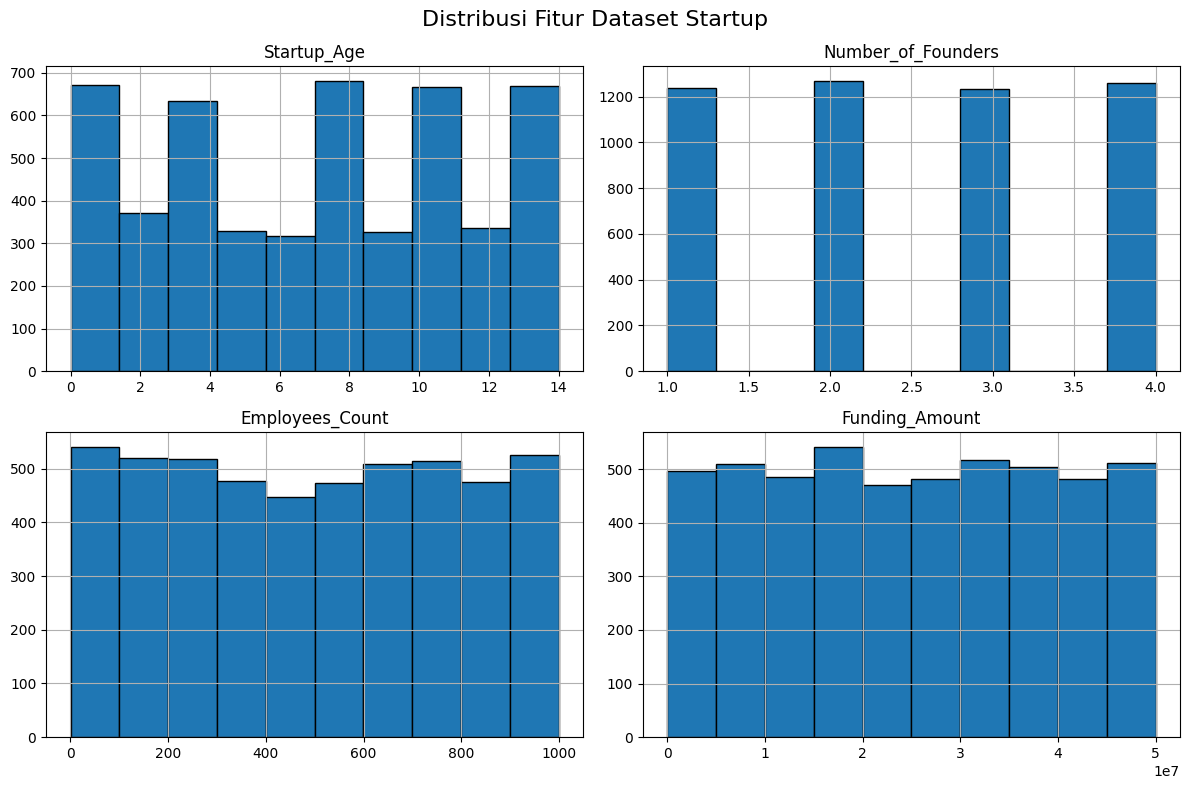


=== PREPROCESSING DATA ===
Preprocessing selesai!

Statistik Fitur Terproses:
       Startup_Age  Funding_Amount  Number_of_Founders  Founder_Experience  \
count  5000.000000    5.000000e+03         5000.000000         5000.000000   
mean      6.992000    2.497341e+07            2.502400           14.740400   
std       4.345816    1.445770e+07            1.117785            8.669212   
min       0.000000    1.120900e+04            1.000000            0.000000   
25%       3.000000    1.250012e+07            2.000000            7.000000   
50%       7.000000    2.496105e+07            2.000000           15.000000   
75%      11.000000    3.747532e+07            4.000000           22.000000   
max      14.000000    4.999313e+07            4.000000           29.000000   

       Employees_Count       Revenue      Burn_Rate  Product_Uniqueness_Score  \
count      5000.000000  5.000000e+03    5000.000000               5000.000000   
mean        496.726800  4.992015e+07  500959.922600     

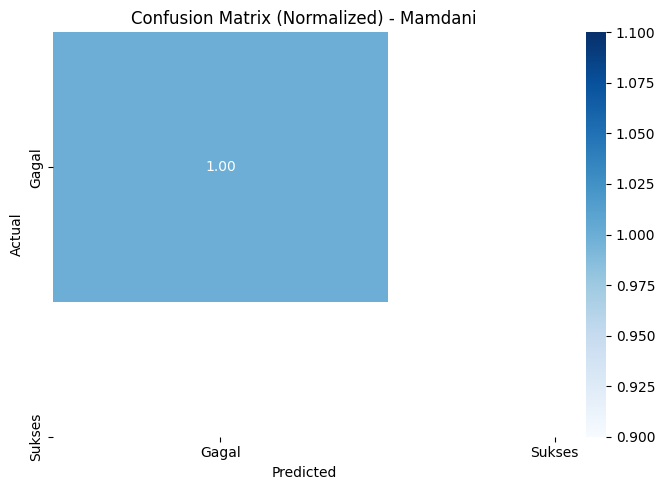

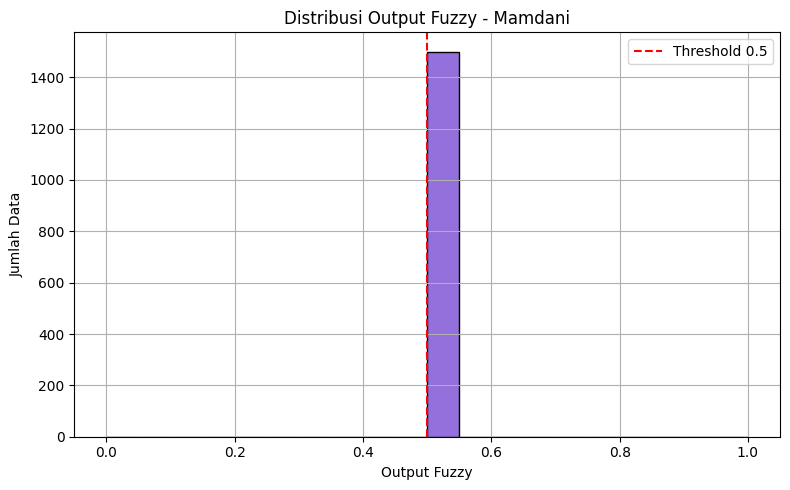


=== EVALUASI SISTEM SUGENO ===
Akurasi Sugeno: 1.0000 (100.00%)
Distribusi y_test: [1500]
Distribusi prediksi: [1500]

Classification Report Sugeno:
              precision    recall  f1-score   support

       Gagal       1.00      1.00      1.00      1500
      Sukses       0.00      0.00      0.00         0

    accuracy                           1.00      1500
   macro avg       0.50      0.50      0.50      1500
weighted avg       1.00      1.00      1.00      1500



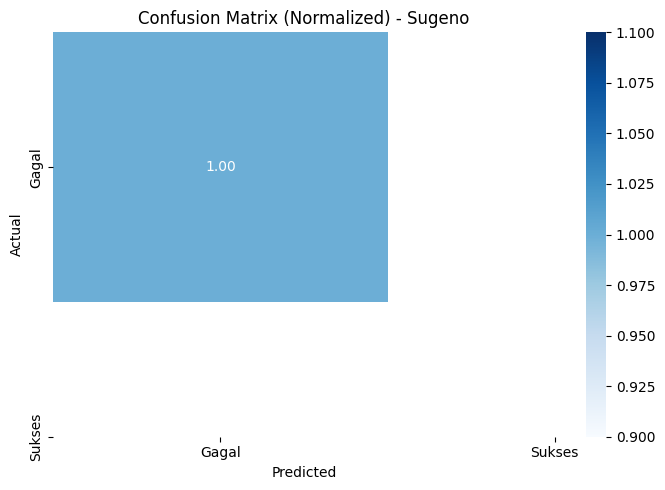

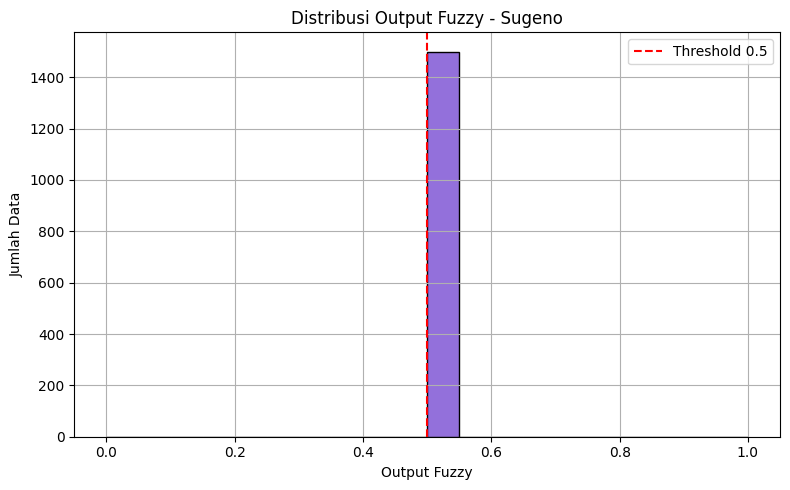


=== PERBANDINGAN HASIL ===
Akurasi Mamdani: 1.0000 (100.00%)
Akurasi Sugeno:  1.0000 (100.00%)
→ Keduanya sama akurat


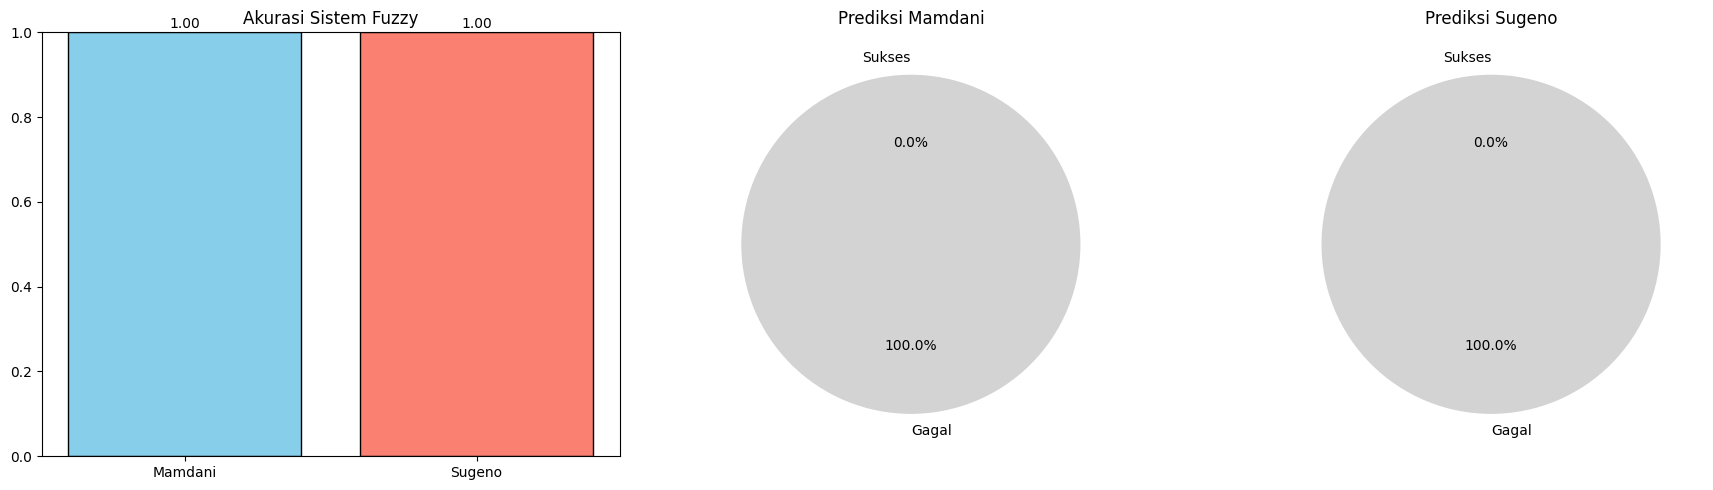


=== ANALISIS PENTINGNYA FITUR ===


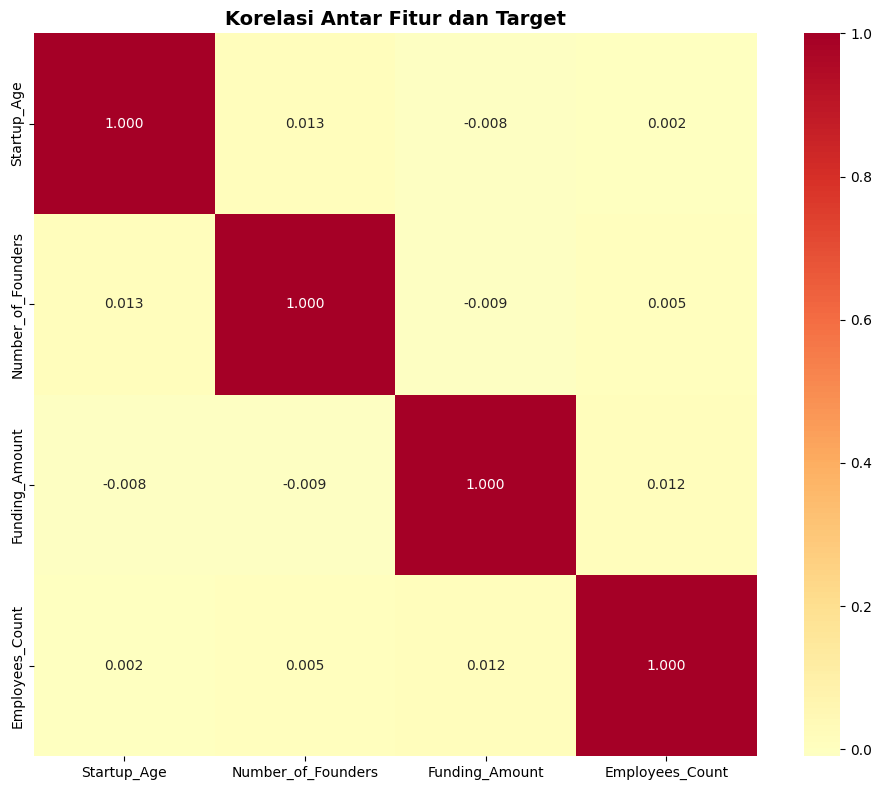

Korelasi fitur dengan Startup_Age (diurutkan):
  Number_of_Founders: 0.013
  Funding_Amount: 0.008
  Employees_Count: 0.002

KESIMPULAN
1. Akurasi Sistem Mamdani: 1.0000 (100.00%)
2. Akurasi Sistem Sugeno:  1.0000 (100.00%)
3. Kedua sistem memiliki performa yang sama

4. Rekomendasi:
   - Pilih berdasarkan kebutuhan: Mamdani untuk interpretabilitas,
     Sugeno untuk efisiensi


In [97]:
results = main()